## With ring metric

In [1]:
import torch
from torch import Tensor
from geodesic_toolbox import CoMetric, CentroidsCometric, IdentityCoMetric, RingCometricBump
from geodesic_toolbox import ExpMapRiemann
from geodesic_toolbox import ImplicitRHMCSampler
import matplotlib.pyplot as plt
import numpy as np


In [2]:
cometric = RingCometricBump(alpha = 0.1)
solver = ExpMapRiemann(cometric)
z_0 = torch.Tensor([[0.,1.]])
v_0 = torch.Tensor([[1., 0.]])

In [3]:
traj_q1, traj_p1 = solver(z_0, v_0)

Leapfrog steps:   0%|          | 0/9 [00:00<?, ?steps/s]

Leapfrog steps: 100%|██████████| 9/9 [00:00<00:00, 14.97steps/s]


In [4]:
cometric = RingCometricBump(alpha = 0.1)
solver = ImplicitRHMCSampler(
    cometric,
    l = 100, 
    N_fx = 6, 
    gamma = 0.01, 
    N_run = 100)
z_0 = torch.Tensor([[0.,1.]])
v_0 = torch.Tensor([[1., 0.]])

In [5]:
traj_q2, traj_p2 = solver.leapfrog(z_0, v_0, return_traj = True)

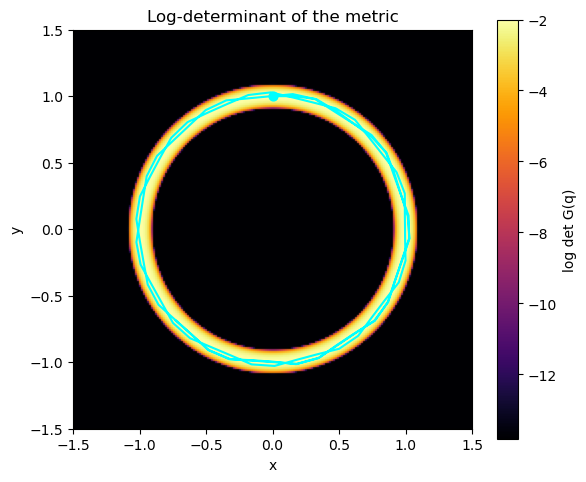

In [6]:
eps = 1e-6

N = 200
x = torch.linspace(-1.5, 1.5, N)
y = torch.linspace(-1.5, 1.5, N)
xx, yy = torch.meshgrid(x, y, indexing="ij")
pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

with torch.no_grad():
    g_inv_diag = cometric(pts)
    det_G = 1.0 / (g_inv_diag[:, 0] * g_inv_diag[:, 1] + eps)

det_G = det_G.reshape(N, N).numpy()
log_det_G = np.log(det_G + eps)

finite = log_det_G[np.isfinite(log_det_G)]
vmax = np.percentile(finite, 100)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    log_det_G.T,
    origin="lower",
    extent=[-1.5, 1.5, -1.5, 1.5],
    cmap="inferno",
    vmin=finite.min(),
    vmax=vmax,
)
fig.colorbar(im, ax=ax, label="log det G(q)")

traj = traj_q2.detach().numpy()  # (b, T, 2)
for b in range(traj.shape[0]):
    ax.plot(traj[b, :, 0], traj[b, :, 1], color="cyan", linewidth=1.5)
    ax.scatter(traj[b, 0, 0], traj[b, 0, 1], color="cyan", marker="o", s=40, zorder=5)

ax.set_title("Log-determinant of the metric")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()


## With centroid cometric

In [7]:
# Generate data as an annulus
n = 1000
theta = torch.rand(n) * 2 * np.pi
r = torch.sqrt(torch.rand(n) * 0.5 + 0.5)
x = r * torch.cos(theta)
y = r * torch.sin(theta)
X = torch.stack([x, y], dim=1)

In [17]:
class MyCentroidsCometric(CentroidsCometric):

    def forward(self, z: Tensor) -> Tensor:
        G_inv = super().forward(z)
        if self.is_diag:
            return 1.0 / G_inv
        return torch.linalg.inv(G_inv)



cometric = MyCentroidsCometric(
    centroids=X,
    cometric_centroids=IdentityCoMetric()(X),
    temperature_scale=0.1,
    K=-1,
)

In [18]:
solver = ImplicitRHMCSampler(
    cometric,
    l = 1000, 
    N_fx = 6, 
    gamma = 0.01, 
    N_run = 100)
z_0 = torch.Tensor([[0.,1.]])
v_0 = torch.Tensor([[1., 0.]])

In [19]:
traj_q2, traj_p2 = solver.leapfrog(z_0, v_0, return_traj = True)

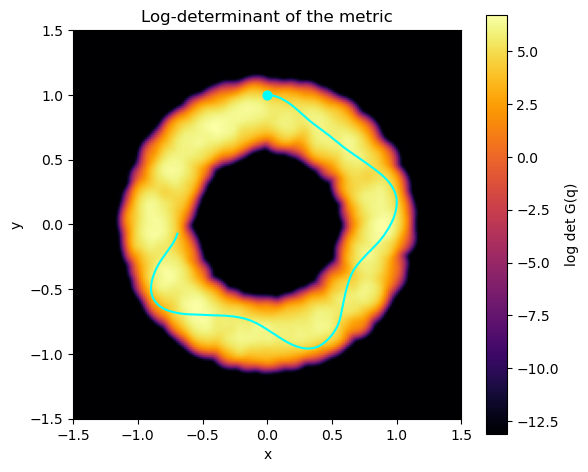

In [20]:
eps = 1e-6

N = 200
x = torch.linspace(-1.5, 1.5, N)
y = torch.linspace(-1.5, 1.5, N)
xx, yy = torch.meshgrid(x, y, indexing="ij")
pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

with torch.no_grad():
    g_inv_diag = cometric(pts)
    det_G = 1.0 / (g_inv_diag[:, 0] * g_inv_diag[:, 1] + eps)

det_G = det_G.reshape(N, N).numpy()
log_det_G = np.log(det_G + eps)

finite = log_det_G[np.isfinite(log_det_G)]
vmax = np.percentile(finite, 100)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    log_det_G.T,
    origin="lower",
    extent=[-1.5, 1.5, -1.5, 1.5],
    cmap="inferno",
    vmin=finite.min(),
    vmax=vmax,
)
fig.colorbar(im, ax=ax, label="log det G(q)")

traj = traj_q2.detach().numpy()  # (b, T, 2)
for b in range(traj.shape[0]):
    ax.plot(traj[b, :, 0], traj[b, :, 1], color="cyan", linewidth=1.5)
    ax.scatter(traj[b, 0, 0], traj[b, 0, 1], color="cyan", marker="o", s=40, zorder=5)

ax.set_title("Log-determinant of the metric")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()
